# Tiny Encoder-Only Transformer

This walkthrough trains one small encoder block to decide whether `A` comes before `B`. It connects the usual Transformer diagram to a complete classifier.

## 1. What I wanted to understand

How does the flow below become one model that can learn an order-sensitive rule?

```text
tokens → token embeddings → positional embeddings → multi-head self-attention
→ residual + LayerNorm → feed-forward network → residual + LayerNorm
→ CLS pooling → classifier → prediction
```

![Tiny Transformer model flow](figures/architecture-flow.svg)

Read the diagram from left to right: the encoder block turns every token into a contextual representation, while the final `[CLS]` vector is used for the sequence-level prediction.

In [1]:
%matplotlib inline

from itertools import combinations, product
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from IPython.display import Markdown, display
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from model import TinyTransformerClassifier

SEED = 7
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)

figures_dir = Path('figures')
figures_dir.mkdir(exist_ok=True)
plt.rcParams['figure.dpi'] = 120

print(f'PyTorch version: {torch.__version__}')

PyTorch version: 2.13.0


## 2. The synthetic task

Every sequence has one `A`, one `B`, and four fillers. The label is balanced exactly: `1` means `A` is before `B`; `0` means `B` is before `A`. Examples are selected without replacement from the finite set of valid sequences, then shuffled deterministically, so no input appears in both splits.

In [2]:
vocabulary = ['[CLS]', 'A', 'B', 'X', 'Y', 'Z']
token_to_id = {token: index for index, token in enumerate(vocabulary)}
id_to_token = {index: token for token, index in token_to_id.items()}
content_length = 6
seq_len = content_length + 1

def make_dataset(num_examples, seed):
    if num_examples % 2 != 0:
        raise ValueError('num_examples must be even to keep the labels balanced')

    generator = torch.Generator().manual_seed(seed)
    filler_ids = range(token_to_id['X'], len(vocabulary))
    sequences_by_label = {0: [], 1: []}

    for label in sequences_by_label:
        first_token, second_token = (token_to_id['A'], token_to_id['B']) if label == 1 else (token_to_id['B'], token_to_id['A'])
        for first_position, second_position in combinations(range(content_length), 2):
            filler_positions = [position for position in range(content_length) if position not in (first_position, second_position)]
            for fillers in product(filler_ids, repeat=len(filler_positions)):
                content = [None] * content_length
                content[first_position] = first_token
                content[second_position] = second_token
                for position, filler in zip(filler_positions, fillers):
                    content[position] = filler
                sequences_by_label[label].append([token_to_id['[CLS]']] + content)

    examples_per_label = num_examples // 2
    if examples_per_label > len(sequences_by_label[0]):
        raise ValueError('num_examples exceeds the number of unique valid sequences')

    token_ids = []
    labels = []
    for label, sequences in sequences_by_label.items():
        selected = torch.randperm(len(sequences), generator=generator)[:examples_per_label].tolist()
        token_ids.extend(sequences[index] for index in selected)
        labels.extend([label] * examples_per_label)

    shuffle_order = torch.randperm(num_examples, generator=generator)
    token_ids = torch.tensor(token_ids)[shuffle_order]
    labels = torch.tensor(labels)[shuffle_order]
    return token_ids, labels

all_token_ids, all_labels = make_dataset(num_examples=1000, seed=SEED)
train_token_ids, validation_token_ids = all_token_ids[:800], all_token_ids[800:]
train_labels, validation_labels = all_labels[:800], all_labels[800:]

sample_tokens = [id_to_token[token_id] for token_id in train_token_ids[0].tolist()]
print('Sample sequence:', ' '.join(sample_tokens))
print('Sample label:', train_labels[0].item(), '(1 means A before B)')
print('Class counts:', torch.bincount(all_labels).tolist())
all_sequences = set(map(tuple, all_token_ids.tolist()))
assert len(all_sequences) == len(all_token_ids)
assert set(map(tuple, train_token_ids.tolist())).isdisjoint(map(tuple, validation_token_ids.tolist()))
print('All generated sequences are unique: True')
print('Train and validation sequences are disjoint: True')
print(f'Token IDs: {list(train_token_ids[:4].shape)} = [batch, seq_len]')

Sample sequence: [CLS] Z X B A Y Y
Sample label: 0 (1 means A before B)
Class counts: [500, 500]
All generated sequences are unique: True
Train and validation sequences are disjoint: True
Token IDs: [4, 7] = [batch, seq_len]


## 3. From tokens to embeddings

Token IDs are lookup keys. The model first maps each one to a learned vector of length `d_model`.

## 4. Positional information

Self-attention alone does not know which position came first. Learned positional embeddings are added to token embeddings before the encoder block.

## 5. One encoder block

The block uses four attention heads, then adds the attention output back to its input and normalizes it. A position-wise FFN follows with the same residual-plus-LayerNorm pattern.

In [3]:
d_model = 32
num_heads = 4
d_ff = 64
num_classes = 2

model = TinyTransformerClassifier(
    vocab_size=len(vocabulary),
    seq_len=seq_len,
    d_model=d_model,
    num_heads=num_heads,
    d_ff=d_ff,
    num_classes=num_classes,
)

example_batch = train_token_ids[:4]
embeddings = model.embed(example_batch)
encoder_output, attention_scores, attention_weights = model.encoder_block(embeddings)
logits = model(example_batch)

print(f'Embeddings: {list(embeddings.shape)} = [batch, seq_len, d_model]')
print(f'Attention scores: {list(attention_scores.shape)} = [batch, heads, seq_len, seq_len]')
print(f'Encoder output: {list(encoder_output.shape)} = [batch, seq_len, d_model]')
print(f'Logits: {list(logits.shape)} = [batch, num_classes]')
print('Attention rows sum to one:', torch.allclose(attention_weights.sum(dim=-1), torch.ones_like(attention_weights.sum(dim=-1))))

Embeddings: [4, 7, 32] = [batch, seq_len, d_model]
Attention scores: [4, 4, 7, 7] = [batch, heads, seq_len, seq_len]
Encoder output: [4, 7, 32] = [batch, seq_len, d_model]
Logits: [4, 2] = [batch, num_classes]
Attention rows sum to one: True


## 6. The complete Tiny Transformer classifier

`TinyTransformerClassifier` combines learned token and position embeddings, one encoder block, and a linear classifier. The final representation at `[CLS]` is a learned summary position passed to that classifier.

## 7. Training loop

This is a plain PyTorch loop: make logits, calculate cross-entropy, backpropagate, update parameters, then measure both splits.

In [4]:
batch_size = 64
epochs = 30
train_loader = DataLoader(
    TensorDataset(train_token_ids, train_labels),
    batch_size=batch_size,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)
validation_loader = DataLoader(TensorDataset(validation_token_ids, validation_labels), batch_size=batch_size)

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.003, weight_decay=0.0001)

def evaluate(loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    with torch.no_grad():
        for token_ids, labels in loader:
            logits = model(token_ids)
            total_loss += loss_function(logits, labels).item() * len(labels)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += len(labels)
    return total_loss / total_examples, total_correct / total_examples

history = {'train_loss': [], 'validation_loss': [], 'train_accuracy': [], 'validation_accuracy': []}

for epoch in range(epochs):
    model.train()
    for token_ids, labels in train_loader:
        logits = model(token_ids)
        loss = loss_function(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss, train_accuracy = evaluate(train_loader)
    validation_loss, validation_accuracy = evaluate(validation_loader)
    history['train_loss'].append(train_loss)
    history['validation_loss'].append(validation_loss)
    history['train_accuracy'].append(train_accuracy)
    history['validation_accuracy'].append(validation_accuracy)

    if epoch in [0, 4, 9, 19, 29]:
        print(f'Epoch {epoch + 1:>2}: train accuracy {train_accuracy:.3f}, validation accuracy {validation_accuracy:.3f}')

Epoch  1: train accuracy 0.490, validation accuracy 0.540
Epoch  5: train accuracy 1.000, validation accuracy 1.000


Epoch 10: train accuracy 1.000, validation accuracy 1.000


Epoch 20: train accuracy 1.000, validation accuracy 1.000


Epoch 30: train accuracy 1.000, validation accuracy 1.000


## 8. Does it learn the task?

Loss should decrease and accuracy should increase if the classifier learns to use positions as well as token identities.

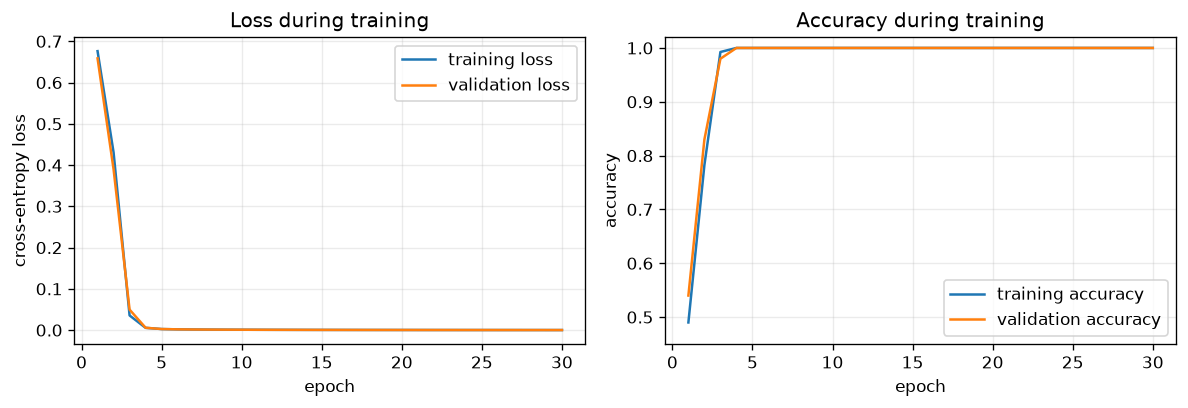

Final training loss: 0.0002
Final validation loss: 0.0002
Final training accuracy: 1.000
Final validation accuracy: 1.000


In [5]:
epochs_axis = range(1, epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(epochs_axis, history['train_loss'], label='training loss')
axes[0].plot(epochs_axis, history['validation_loss'], label='validation loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('cross-entropy loss')
axes[0].set_title('Loss during training')
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(epochs_axis, history['train_accuracy'], label='training accuracy')
axes[1].plot(epochs_axis, history['validation_accuracy'], label='validation accuracy')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].set_ylim(0.45, 1.02)
axes[1].set_title('Accuracy during training')
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.tight_layout()
fig.savefig(figures_dir / 'training-curves.png', bbox_inches='tight')
plt.show()

print(f'Final training loss: {history["train_loss"][-1]:.4f}')
print(f'Final validation loss: {history["validation_loss"][-1]:.4f}')
print(f'Final training accuracy: {history["train_accuracy"][-1]:.3f}')
print(f'Final validation accuracy: {history["validation_accuracy"][-1]:.3f}')

## 9. Inspecting predictions

These rows come from the held-out validation split. Confidence is the softmax probability assigned to the predicted class.

In [6]:
model.eval()
with torch.no_grad():
    validation_logits = model(validation_token_ids)
    validation_probabilities = torch.softmax(validation_logits, dim=1)
    validation_predictions = validation_probabilities.argmax(dim=1)

selected_indices = range(4)

table_lines = ['| tokens | true label | predicted label | confidence |', '| --- | ---: | ---: | ---: |']
for index in selected_indices:
    tokens = ' '.join(id_to_token[token_id] for token_id in validation_token_ids[index].tolist())
    prediction = validation_predictions[index].item()
    confidence = validation_probabilities[index, prediction].item()
    table_lines.append(f'| `{tokens}` | {validation_labels[index].item()} | {prediction} | {confidence:.3f} |')

display(Markdown('\n'.join(table_lines)))

| tokens | true label | predicted label | confidence |
| --- | ---: | ---: | ---: |
| `[CLS] B A X Y X Z` | 0 | 0 | 1.000 |
| `[CLS] A Z Y Z B X` | 1 | 1 | 1.000 |
| `[CLS] A Z Z B Z Y` | 1 | 1 | 1.000 |
| `[CLS] X Z A Y Z B` | 1 | 1 | 1.000 |

## 10. What I learned

In this recorded run, validation accuracy reached `1.000` by epoch 5 and remained there through epoch 30; final validation cross-entropy was `0.0002`. This task isolates one useful role of learned positional embeddings: the model must distinguish identical token counts arranged in different orders.